<a href="https://colab.research.google.com/github/cosmicurvy/amazon-reviews-nlp/blob/main/notebooks/TopicModeling_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install gensim

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk # to preprocess text data
import re
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer # to convert text into numbers
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import LatentDirichletAllocation # for topic modeling
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
dataset_path = '/content/drive/MyDrive/Sentiment-Classification/Musical_Instruments.jsonl.gz'
data = pd.read_json(dataset_path, lines=True, compression='gzip')

In [5]:
data.sample(3)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
2306460,5,Great tuner,Great tuner. Can see on dark stage well or in ...,[],B00MO6KKSK,B0BCK6L7S5,AG7XW4LJVWW2YLZXR3NYLBKH3SYA,2016-12-31 21:22:44.000,0,True
2599419,5,Fits great!,"Love the pocket, great cover",[],B091D75BGQ,B091D75BGQ,AGP3NB27EF2QOAK5PYR3VPU2VSLQ,2021-12-03 14:49:38.561,0,True
1461259,5,Excellent,These are very good microphones for video reco...,[],B0BGLMJB91,B0CGR8T7PJ,AGNHXUSRFJUHOCE3CCEDTTDT3WGA,2023-03-16 20:47:30.246,0,True


In [6]:
# extract the required features
data = data[['title','text','rating']]

In [7]:
data.shape

(3017439, 3)

In [8]:
print("Total Duplicate Values: ", data.duplicated().sum())

Total Duplicate Values:  179889


In [9]:
# drop duplicate values
data = data.drop_duplicates()
data.shape

(2837550, 3)

- The dataset is very large, so we use a sample of 50,000 data points.

In [10]:
data = data.sample(50000, random_state = 35)
data.shape

(50000, 3)

In [11]:
sample_data_path = '/content/drive/MyDrive/Sentiment-Classification/'

# save the  sample Dataset
data.to_csv(sample_data_path+'amazon_reviews.csv', index=False)

In [12]:
df = pd.read_csv("/content/drive/MyDrive/Sentiment-Classification/amazon_reviews.csv")
df.sample(5)

,title,text,rating
41404,Excellent!,This is by far the best Capo I have purchased....,5
37342,excellent,This case is well made. it fits my husband's ...,5
1139,GreAr vAlue,Easy to use,5
34948,Great accessorie for Uke,Works as advertised!,5
48182,Fantastic,I am very pleased with this product. It is wor...,5


In [13]:
df.shape

(50000, 3)

In [14]:
df.isna().sum()

,0
title,6
text,5
rating,0


In [15]:
df.dropna(inplace=True)

In [16]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
rating,49989.0,4.22619,1.295281,1.0,4.0,5.0,5.0,5.0


### EDA

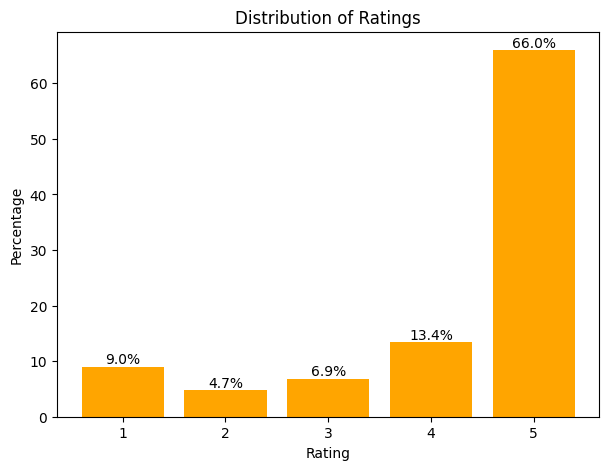

In [17]:
# visualize the distribution of ratings
categories = df.rating.value_counts(normalize=True).index
percentages = df.rating.value_counts(normalize=True).values * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(categories, percentages, color='orange')
plt.bar_label(bars, fmt='%.1f%%')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Percentage")
plt.show()

- Most products received a 5‑star rating, indicating that the majority of reviews are positive. This shows a significant class imbalance in the data.

In [18]:
df['length'] = df['text'].apply(lambda x: len(x))

In [19]:
# function to get the sentiment for each review
def get_sentiment(rate):
  if rate in [1, 2]:
    return 'Negative'
  elif rate == 3:
    return "Neutral"
  else:
    return "Positive"

df['sentiment'] = df['rating'].apply(get_sentiment)

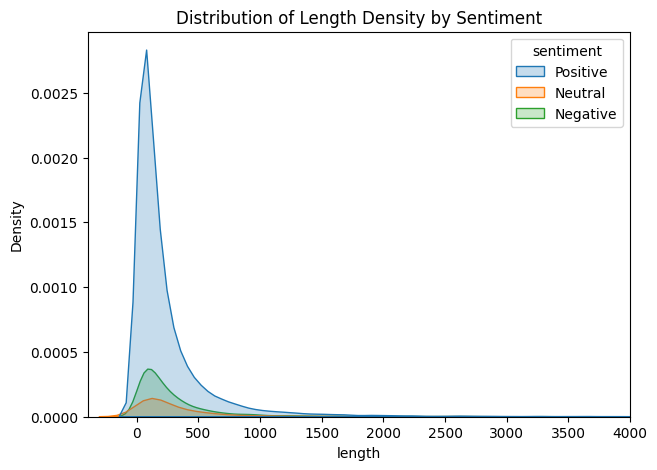

In [20]:
# visualize the reviews length density per sentiment
plt.figure(figsize=(7,5))
sns.kdeplot(data=df, x= 'length', hue='sentiment', fill=True)

plt.title("Distribution of Length Density by Sentiment")
plt.xlim(-400, 4000)
plt.show()

### Text Preprocessing

- Before performing topic modeling, we preprocess the reviews.


In [21]:
lemmatizer = WordNetLemmatizer()
stop_words = stopwords.words('english')

# function to clean the text
def preprocess_txt(text):
  text = text.lower()
  cleaned = re.sub(r'(<br\s*/?>)+', ' ', text)
  cleaned = re.sub(r'[^a-zA-Z0-9]', ' ', cleaned)
  tokens = word_tokenize(cleaned)
  cleaned_tokens = [lemmatizer.lemmatize(token) for token in tokens if not token in stop_words]
  cleaned_txt = ' '.join(cleaned_tokens)
  return cleaned_txt

df['preprocessed_text'] = df['text'].apply(lambda x: preprocess_txt(x))

In [22]:
df.head(3)

,title,text,rating,length,sentiment,preprocessed_text
0,BEST protection for many equipment needs!,I purchased the SKB mid-sized hardware case af...,5,777,Positive,purchased skb mid sized hardware case trying s...
1,Good value,"Well made, good fit & finish, does the job! I...",5,136,Positive,well made good fit finish job want spend money...
2,Nice for gaming,Sound quality is very good for gaming and onli...,5,56,Positive,sound quality good gaming online class


### Topic Modeling

- We perform topic modeling only on negative reviews to group different kinds of issues or complaints the users are facing.

In [23]:
# filter negative reviews
data_tm = df[df['sentiment'] == 'Negative']

In [24]:
data_tm.shape

(6874, 6)

In [25]:
# stop words for countvectorizer
overlapping_noise = ['product', 'work', 'worked', 'working', 'stopped', 'like', 'even', 'use', 'back', 'got', 'time',
                     'first', 'item', 'came', 'didnt', 'doesnt', 'one', 'get', 'would', 'really', 'much', 'using',
                     'way', 'good', 'great', 'bad', 'buy', 'bought', 'quality', '34']

- We apply Bag-of-Words (BoW) model via CountVectorizer to convert unstructured text into numerical feature.

- During topic modeling, we notice significant word overlap between topics, so we pass those words to the stop_words in the CountVectorizer to reduce redundancy.

In [26]:
# initialize the vectorizer
vectorizer = CountVectorizer(stop_words= overlapping_noise, lowercase=False, max_df=0.75, min_df=5)
doc_matrix = vectorizer.fit_transform(data_tm['preprocessed_text']) # fit on negative reviwews
feature_names = vectorizer.get_feature_names_out()

In [27]:
#LDA
lda_model = LatentDirichletAllocation(n_components=3, random_state=42, max_iter=15)
lda_model.fit(doc_matrix)

LatentDirichletAllocation(max_iter=15, n_components=3, random_state=42)

In [28]:
# extract top 15 words per topic
topics = []

for topic in lda_model.components_:
  top_words = [feature_names[i] for i in topic.argsort()[-15:][::-1]]
  topics.append(top_words)

In [29]:
analyzer = vectorizer.build_analyzer()

# this ensures gensim evaluates the exact same token scikit-learn processed
cleaned_tokens = [analyzer(doc) for doc in data_tm['preprocessed_text']]

In [30]:
# create a dictionary
gensim_dict = Dictionary(cleaned_tokens)

- We use the Coherence score to evaluate the LDA topics, it measures how clear (semantically meaningful) the topics are.

In [31]:
# initialize the coherence model
coherence_model = CoherenceModel(topics= topics, texts = cleaned_tokens, dictionary= gensim_dict,  coherence='c_v')

print("Coherence Score: ", coherence_model.get_coherence())

Coherence Score:  0.46466163281479983


In [32]:
for topic in topics:
  print(topic)

['return', 'month', 'day', 'broke', 'received', 'week', 'amazon', 'year', 'new', 'never', 'used', 'two', 'box', 'light', 'money']
['sound', 'mic', 'cable', 'microphone', 'pedal', 'speaker', 'noise', 'power', 'make', 'audio', 'amp', 'volume', 'unit', 'tried', 'could']
['guitar', 'string', 'stand', 'fit', 'cheap', 'sound', 'play', 'made', 'look', 'better', 'hold', 'plastic', 'instrument', 'well', 'tune']


In [33]:
topic0 = "'return', 'month', 'day', 'broke', 'received', 'week', 'amazon', 'year', 'new', 'never', 'used', 'two', 'box', 'light', 'money'"
topic1 ="'sound', 'mic', 'cable', 'microphone', 'pedal', 'speaker', 'noise', 'power', 'make', 'audio', 'amp', 'volume', 'unit', 'tried', 'could'"
topic2 ="''guitar', 'string', 'stand', 'fit', 'cheap', 'sound', 'play', 'made', 'look', 'better', 'hold', 'plastic', 'instrument', 'well', 'tune'"

In [34]:
# function for  word cloud
def generate_wordcloud(words, topic):
  wc = WordCloud(width=900,height=600, background_color='black').generate(words)
  plt.title(f"{topic}")
  plt.imshow(wc)
  plt.axis('off')
  plt.tight_layout()

### WordCloud

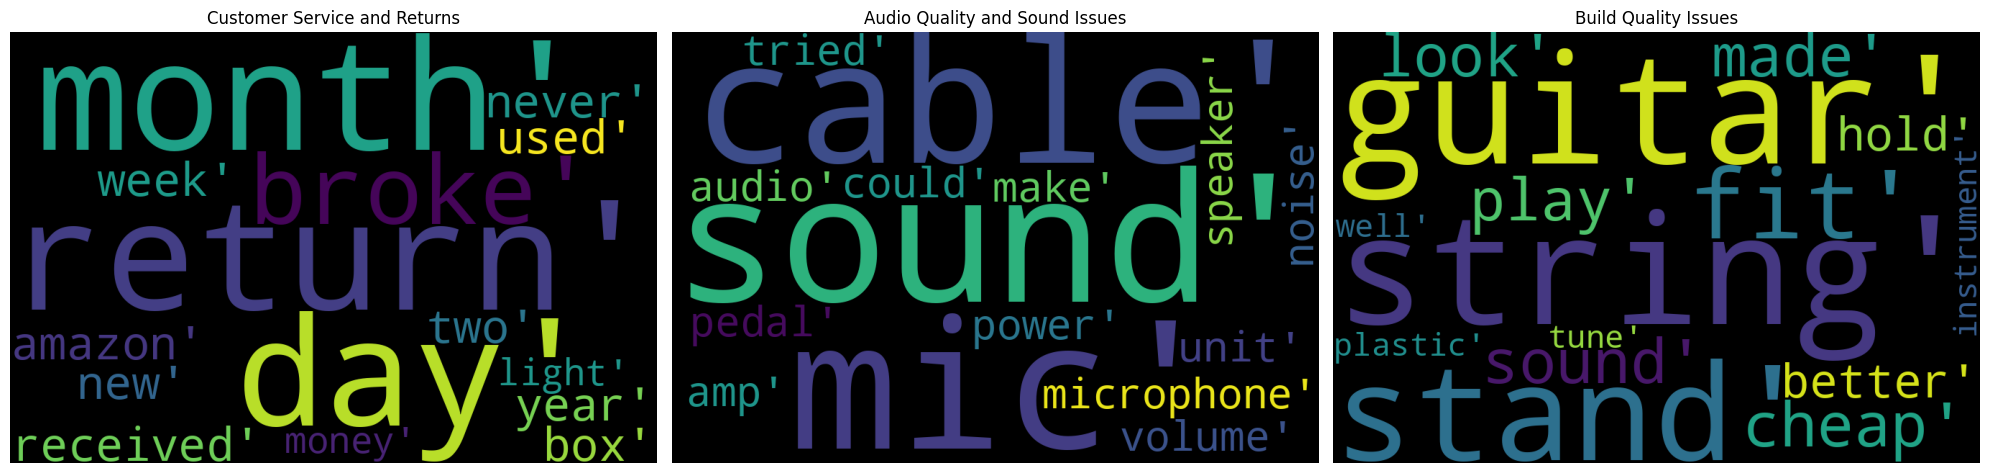

In [36]:
plt.figure(figsize=(20,20))

plt.subplot(1,3,1)
generate_wordcloud(words= topic0, topic="Customer Service and Returns")

plt.subplot(1,3,2)
generate_wordcloud(words= topic1, topic="Audio Quality and Sound Issues")

plt.subplot(1,3,3)
generate_wordcloud(words= topic2, topic="Build Quality Issues")

In [ ]:
# get the topic probabilities
topic_probabilities = lda_model.transform(doc_matrix)
topic_names = {0: 'Customer Service and Returns', 1: 'Audio Quality and Sound Issues', 2: 'Build Quality Issues'}

# create new columns
data_tm['topic'] = topic_probabilities.argmax(axis=1)
data_tm['topic_probs'] = topic_probabilities.max(axis=1)
data_tm['topic_name'] = data_tm['topic'].map(topic_names)

In [38]:
data_tm.sample(3)

,title,text,rating,length,sentiment,preprocessed_text,topic,topic_probs,topic_name
8482,Produces a Loud Humming Sound,I purchased this product to make my electric g...,1,787,Negative,purchased product make electric guitar sound l...,1,0.743309,Audio Quality and Sound Issues
34681,Little to no sound,Terrible sound quality. Would’ve returned if w...,1,71,Negative,terrible sound quality would returned miss window,1,0.835938,Audio Quality and Sound Issues
25370,Need Instructions,The were NO instructions at all. Only this one...,2,52,Negative,instruction one card,0,0.755378,Customer Service and Returns


In [40]:
# extract top 5 reviews for each topic
top_reviews = pd.DataFrame()

for topic_id in topic_names.keys():
  top_5 = data_tm[data_tm['topic']== topic_id].sort_values(by='topic_probs', ascending=False).head(5)
  top_reviews = pd.concat([top_reviews, top_5])

- To make the model results easier to interpret, we show the original raw review text for each topic rather than the preprocessed text.

In [41]:
print("Top 5 Reviews of Topic 0 (Customer Service and Returns) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[:5, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 0 (Customer Service and Returns) -->


1) They sent different model rack. It is not MDS-KVX. I chose drum throne bundle, it is missing too. Pretty disappointed with the purchase.<br ...
2) I successfully installed this program, but to run it you need to "activate" it - enter your name, the serial number, your email address and ...
3) The TASCAM US-2x2 has been discontinued, so don't buy it, but also don't buy it because mine stopped working in less than a year, and appare...
4) El articulo está bien diseñado y fabricado pero no corresponde al mostrado en la imagen y el video. Por comodidad y ergonomia, prefiero el d...
5) I will update my review to say that it has now been three weeks since I contacted 1byone's customer service and I still have not heard from ...


In [42]:
print("Top 5 Reviews of Topic 1 (Audio Quality and Sound Issues) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[5:10, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 1 (Audio Quality and Sound Issues) -->


1) I bought these because I needed something to go from a 3.5 mm TRS (tip-ring-sleeve) connector to XLM male - so far, so good. However, in my ...
2) I see lots of positive reviews so let me get to the reason this was returned.<br />It's not a serious mixer if so it would be powered by a r...
3) The touchpad, while certainly responsive, is not polyphonic or pressure sensitive. You cannot sound two or more notes on the touchpad at the...
4) Took a while to figure out the complex ASIO Driver Utility on Windows 10 Pro 64, but I got the hang of it in a few hours.<br /><br />My use ...
5) I had to adjust my review as I became more familiar with the item. I mainly wanted to use this to record lectures and church services. After...


In [43]:
print("Top 5 Reviews of Topic 2 (Build Quality Issues) -->")
print("\n")

for i, review in enumerate(top_reviews.iloc[10:, :]['text'], start=1):
  print(f"{i}) {review[:140]}...")

Top 5 Reviews of Topic 2 (Build Quality Issues) -->


1) Update 8/17/2021:  at first this ukulele was not bad after doing a set up. As time went on the neck began to bow… and bow… and bow.  There w...
2) I was skeptical about some of the reviews for this guitar. Issues with tuning and string tension are quite normal for new guitars (incl. exp...
3) In short, it's too small. I have two guitars - a Squier Strat and an Epiphone SG400. I measured them both from the rear strap button to the ...
4) This stand is an assembly required product that fits together with ease, the part having interlocking tabs and slots cut into the wood.  Don...
5) I have had the stand for two weeks now.  It seems solid but large for my needs.  The three legs expand 24&#34; apart, which makes the stand ...


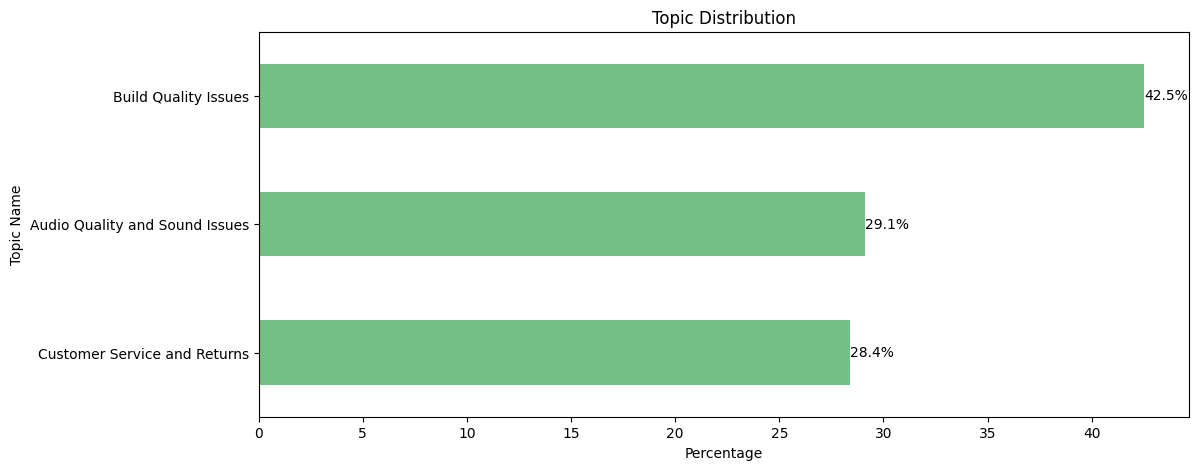

In [44]:
# visualize the topic distribution
plt.figure(figsize= (12,5))

ax = (data_tm['topic_name'].value_counts(normalize=True) * 100).sort_values().plot(kind='barh', color='#73bf85')
for container in ax.containers:
  ax.bar_label(container, fmt='%.1f%%')

plt.title("Topic Distribution")
plt.xlabel('Percentage')
plt.ylabel("Topic Name")
plt.show()

- Most of the reviews fall under the "Build Quality Issues" topic (Topic 2).

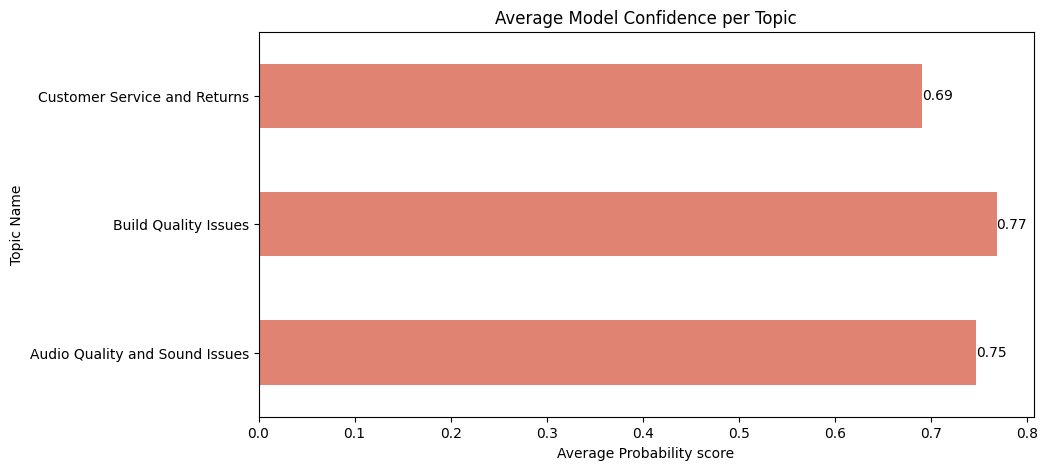

In [46]:
# visualize the average model confidence
plt.figure(figsize= (10,5))
ax = data_tm.groupby('topic_name')['topic_probs'].mean().plot(kind='barh', color='#e08372')

for container in ax.containers:
  ax.bar_label(container, fmt= '%.2f')

plt.title("Average Model Confidence per Topic")
plt.xlabel('Average Probability score')
plt.ylabel("Topic Name")
plt.show()

- Average probability score is higher for "Build Quality Issues" topic, followed by "Audio Quality and Sound Issues".